In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob


#### Cargar datos

In [52]:
ruta = "Datos/Originales/DowJones"
files = glob.glob(os.path.join(ruta, "*.csv"))

dataframes = []
for file in files:
    df_temp = pd.read_csv(file)
    dataframes.append(df_temp)

# Concatenar todos en un único DataFrame
df = pd.concat(dataframes, ignore_index=True)
print("Filas totales (raw):", len(df))
print(df.head())


Filas totales (raw): 2744418
      open    high      low  last    close  volume                      date  \
0  213.370  213.41  213.300   NaN  213.300     NaN  2018-08-16T21:30:00+0000   
1  213.280  213.41  213.160   NaN  213.300     NaN  2018-08-16T21:00:00+0000   
2  213.430  213.43  212.985   NaN  213.280     NaN  2018-08-16T20:30:00+0000   
3  213.133  213.73  212.985   NaN  213.480     NaN  2018-08-16T20:00:00+0000   
4  213.273  213.30  213.133   NaN  213.133     NaN  2018-08-16T19:30:00+0000   

  symbol exchange  
0   AAPL     IEXG  
1   AAPL     IEXG  
2   AAPL     IEXG  
3   AAPL     IEXG  
4   AAPL     IEXG  


In [54]:
# Assumo que 'df' es tu DataFrame original (concatenado de todos los CSV)
print("Filas totales raw:", len(df))
print("\nNaNs por columna (raw):")
print(df.isna().sum())

# Cuántas filas tienen ANY NaN
print("\nFilas con algún NaN (raw):", df.isna().any(axis=1).sum())

# Mostrar algunas filas con NaNs para ver patrones
display(df[df.isna().any(axis=1)].head(10))


Filas totales raw: 2744418

NaNs por columna (raw):
open             0
high             0
low              0
last        849956
close       611651
volume      847408
date             0
symbol           0
exchange         0
dtype: int64

Filas con algún NaN (raw): 850281


,open,high,low,last,close,volume,date,symbol,exchange
0,213.370,213.410,213.300,NaN,213.300,NaN,2018-08-16T21:30:00+0000,AAPL,IEXG
1,213.280,213.410,213.160,NaN,213.300,NaN,2018-08-16T21:00:00+0000,AAPL,IEXG
2,213.430,213.430,212.985,NaN,213.280,NaN,2018-08-16T20:30:00+0000,AAPL,IEXG
3,213.133,213.730,212.985,NaN,213.480,NaN,2018-08-16T20:00:00+0000,AAPL,IEXG
4,213.273,213.300,213.133,NaN,213.133,NaN,2018-08-16T19:30:00+0000,AAPL,IEXG
5,212.785,213.465,212.785,NaN,213.133,NaN,2018-08-16T19:00:00+0000,AAPL,IEXG
6,212.850,213.198,212.785,NaN,212.785,NaN,2018-08-16T18:30:00+0000,AAPL,IEXG
7,211.780,213.198,211.780,NaN,212.785,NaN,2018-08-16T18:00:00+0000,AAPL,IEXG
8,210.240,212.250,210.240,NaN,211.780,NaN,2018-08-16T17:30:00+0000,AAPL,IEXG
9,210.240,210.240,210.240,NaN,210.240,NaN,2018-08-16T00:00:00+0000,AAPL,IEXG


Convertir columna fecha a datetime

In [ ]:
df["raw_date"] = df["date"]  # guardamos string original
df["date"] = pd.to_datetime(df["date"], utc=True, errors="coerce")


Detectar si es horario español

In [56]:
def es_espanol(row):
    raw = str(row["raw_date"])
    exch = str(row.get("exchange", "")).upper()
    # Si la cadena original lleva +01 o +02 -> horarios CET/CEST
    if "+01" in raw or "+02" in raw:
        return True
    # Si el exchange es español
    if exch in {"BME", "MC", "MCE", "BME.MC"}:
        return True
    return False

df["es_espanol"] = df.apply(es_espanol, axis=1)


# -----------------------
# 4. Restar 6 horas a horarios españoles
# -----------------------
# df.loc[df["es_espanol"], "date"] = df.loc[df["es_espanol"], "date"] - pd.Timedelta(hours=6)



En vez de restar 6 horas siempre, se usa tz_convert (Europe/Madrid → America/New_York).

Esto evita problemas en cambios de horario de verano y asigna la fecha correcta.

In [57]:
# Aquí en vez de restar 6 horas fijo, convertimos timezone:
# - Los que marcamos como españoles, los convertimos de Europe/Madrid a America/New_York
# - El resto ya está en UTC y se pasa directo a America/New_York
df["date"] = pd.to_datetime(df["raw_date"], errors="coerce")

# Localizamos en la zona adecuada
df.loc[df["es_espanol"], "date"] = (
    pd.to_datetime(df.loc[df["es_espanol"], "raw_date"], utc=True)
    .dt.tz_convert("Europe/Madrid")
    .dt.tz_convert("America/New_York")
)

df.loc[~df["es_espanol"], "date"] = (
    pd.to_datetime(df.loc[~df["es_espanol"], "raw_date"], utc=True)
    .dt.tz_convert("America/New_York")
)

In [58]:
df.head()

,open,high,low,last,close,volume,date,symbol,exchange,raw_date,es_espanol
0,213.370,213.41,213.300,NaN,213.300,NaN,2018-08-16 21:30:00+00:00,AAPL,IEXG,2018-08-16T21:30:00+0000,False
1,213.280,213.41,213.160,NaN,213.300,NaN,2018-08-16 21:00:00+00:00,AAPL,IEXG,2018-08-16T21:00:00+0000,False
2,213.430,213.43,212.985,NaN,213.280,NaN,2018-08-16 20:30:00+00:00,AAPL,IEXG,2018-08-16T20:30:00+0000,False
3,213.133,213.73,212.985,NaN,213.480,NaN,2018-08-16 20:00:00+00:00,AAPL,IEXG,2018-08-16T20:00:00+0000,False
4,213.273,213.30,213.133,NaN,213.133,NaN,2018-08-16 19:30:00+00:00,AAPL,IEXG,2018-08-16T19:30:00+0000,False


 Pasar a diario por accion

In [59]:
df = df.sort_values(["symbol", "date"])

# función auxiliar
def a_diario(g):
    g = g.set_index("date")
    diario = g.resample("D").agg({
        "open": "first",
        "high": "max",
        "low": "min",
        "close": "last",
        "volume": "sum"
    })
    # rellenar huecos (festivos/domingos)
    diario = diario.ffill()
    return diario  

df_daily = df.groupby("symbol").apply(a_diario).reset_index()
print("Filas diarias:", len(df_daily))
print(df_daily.head())


Filas diarias: 14678
  symbol                      date    open    high      low   close  volume
0   AAPL 2018-06-06 00:00:00+00:00  193.63  194.00  191.950  194.00     0.0
1   AAPL 2018-06-07 00:00:00+00:00  194.00  194.16  192.385  193.50     0.0
2   AAPL 2018-06-08 00:00:00+00:00  193.50  193.50  189.805  191.51     0.0
3   AAPL 2018-06-09 00:00:00+00:00  191.51  191.51  191.510  191.51     0.0
4   AAPL 2018-06-10 00:00:00+00:00  191.51  191.51  191.510  191.51     0.0


 Detectar splits (saltos grandes en close)

además de la heurística básica (ratio <0.6 o >1.6), ahora calculo un approx_split_factor y su closeness a un entero, para diferenciar splits claros (2:1, 3:1, 4:1).

In [60]:
split_list = []
for sym, g in df_daily.groupby("symbol"):
    g = g.sort_values("date")
    g["ratio"] = g["close"] / g["close"].shift(1)
    eventos = g[(g["ratio"] < 0.6) | (g["ratio"] > 1.6)]
    if not eventos.empty:
        split_list.append(eventos[["date", "symbol", "close", "ratio"]])

if split_list:
    df_splits = pd.concat(split_list)
    print("\nPosibles splits detectados:")
    print(df_splits)
else:
    print("\nNo se detectaron splits.")



Posibles splits detectados:
                         date symbol   close     ratio
818 2020-09-01 00:00:00+00:00   AAPL  129.04  0.258478


? (eso me ha dicho chati pero ns) Lo más probable es que tu proveedor ya ajuste la mayoría de los splits (por eso solo sale uno), o que tu heurística/resampling/shift de timezone haya movido o atenuado otros saltos.

In [61]:
cand = []
for sym, g in df_daily.groupby("symbol"):
    g = g.sort_values("date").copy()
    g["ratio"] = g["close"] / g["close"].shift(1)
    for idx, row in g.dropna(subset=["ratio"]).iterrows():
        r = row["ratio"]
        if r <= 0:
            continue
        if r < 0.9 or r > 1.1:  # saltos relevantes
            if r < 1:
                inv = 1.0 / r
                approx = int(round(inv))
                closeness = abs(inv - approx)
            else:
                approx = int(round(r))
                closeness = abs(r - approx)
            cand.append({
                "symbol": row["symbol"],
                "date": row["date"],
                "close": row["close"],
                "ratio": r,
                "approx_split_factor": approx,
                "closeness": closeness
            })

cand_df = pd.DataFrame(cand).sort_values(["symbol", "date"])
print("Candidatos a splits (ordenado):")
display(cand_df)

# Filtra los que son más "claros" (cercanos a entero)
print("\nPosibles splits claros:")
display(cand_df[cand_df["closeness"] < 0.12])


Candidatos a splits (ordenado):


,symbol,date,close,ratio,approx_split_factor,closeness
0,AAPL,2020-03-13 00:00:00+00:00,278.020,1.119514,1,0.119514
1,AAPL,2020-03-16 00:00:00+00:00,241.830,0.869830,1,0.149651
2,AAPL,2020-03-24 00:00:00+00:00,246.600,1.100991,1,0.100991
3,AAPL,2020-08-03 00:00:00+00:00,425.040,1.104689,1,0.104689
4,AAPL,2020-09-01 00:00:00+00:00,129.040,0.258478,4,0.131200
5,AXP,2020-06-11 00:00:00+00:00,98.610,0.867511,1,0.152723
6,AXP,2020-11-10 00:00:00+00:00,117.370,1.213879,1,0.213879
7,BA,2020-06-04 00:00:00+00:00,173.160,1.143801,1,0.143801
8,BA,2020-06-08 00:00:00+00:00,205.430,1.114650,1,0.114650
9,BA,2020-06-09 00:00:00+00:00,230.500,1.122037,1,0.122037



Posibles splits claros:


,symbol,date,close,ratio,approx_split_factor,closeness
0,AAPL,2020-03-13 00:00:00+00:00,278.020,1.119514,1,0.119514
2,AAPL,2020-03-24 00:00:00+00:00,246.600,1.100991,1,0.100991
3,AAPL,2020-08-03 00:00:00+00:00,425.040,1.104689,1,0.104689
8,BA,2020-06-08 00:00:00+00:00,205.430,1.114650,1,0.114650
11,BA,2020-06-12 00:00:00+00:00,189.410,1.112998,1,0.112998
16,CAT,2020-03-24 00:00:00+00:00,101.470,1.104495,1,0.104495
20,CVX,2020-11-10 00:00:00+00:00,79.400,1.115952,1,0.115952
22,DIS,2020-11-10 00:00:00+00:00,142.590,1.118704,1,0.118704
25,GS,2020-03-09 00:00:00+00:00,172.775,0.895532,1,0.116655
31,IBM,2020-06-15 00:00:00+00:00,121.910,0.898048,1,0.113526


Graficar cada símbolo y ver si los splits

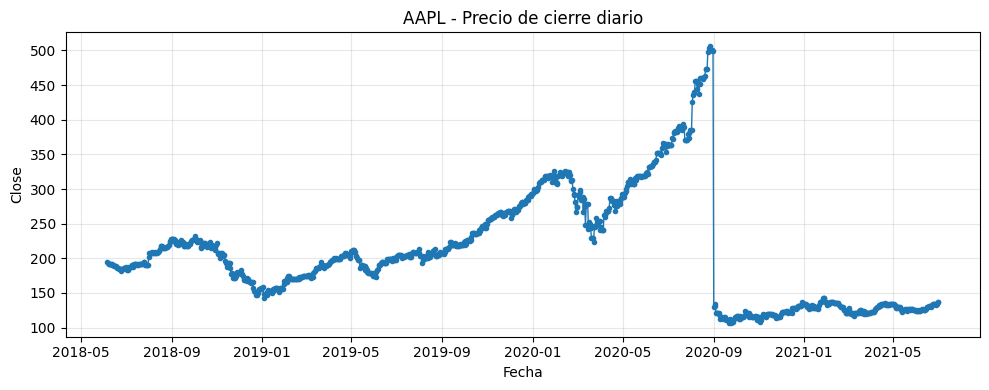

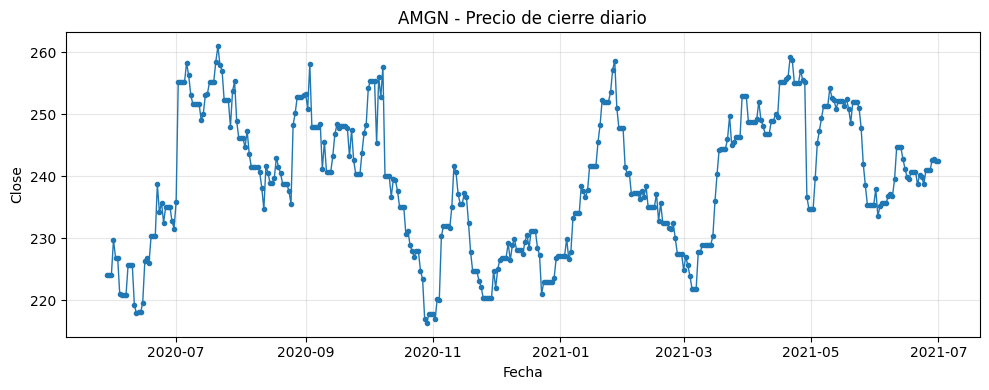

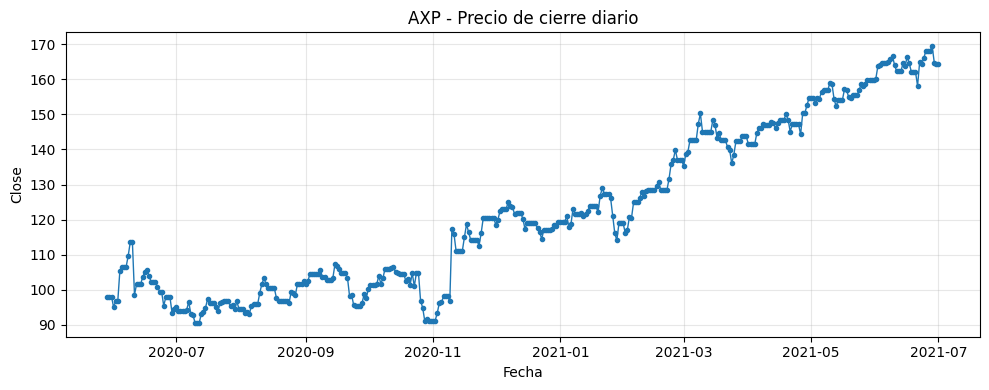

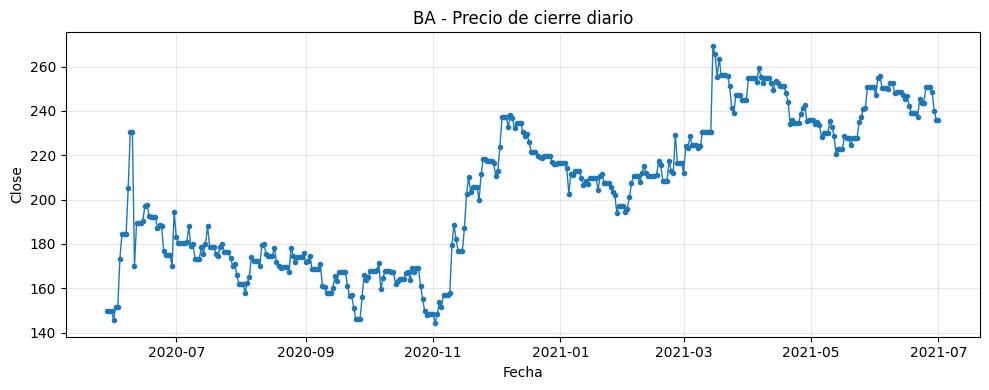

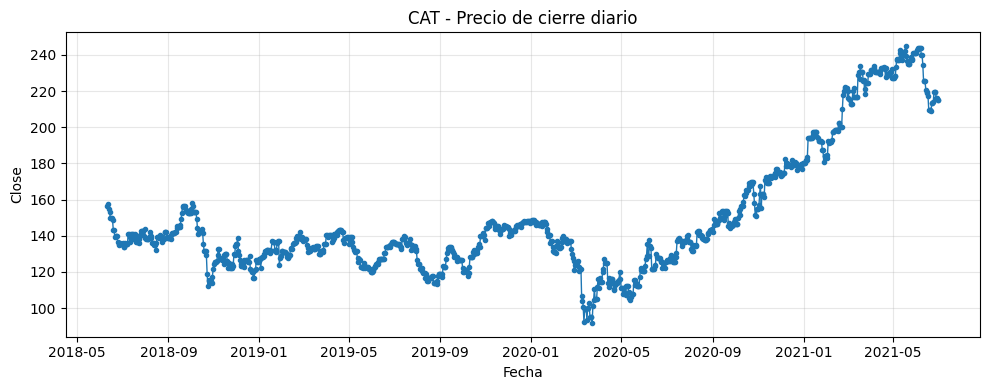

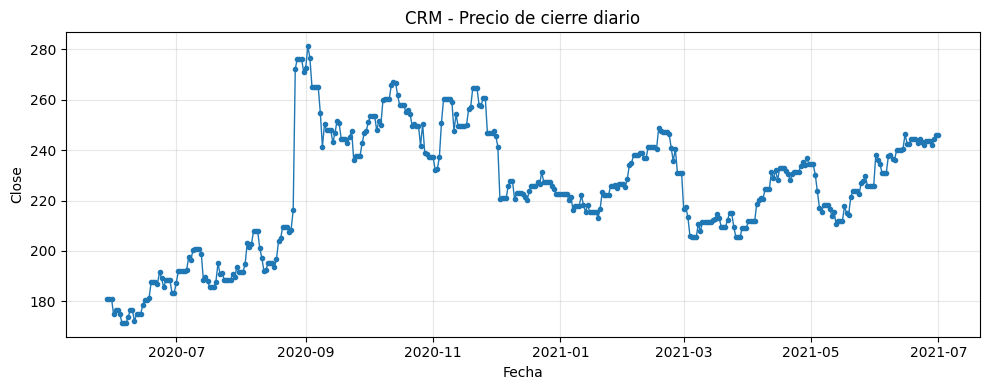

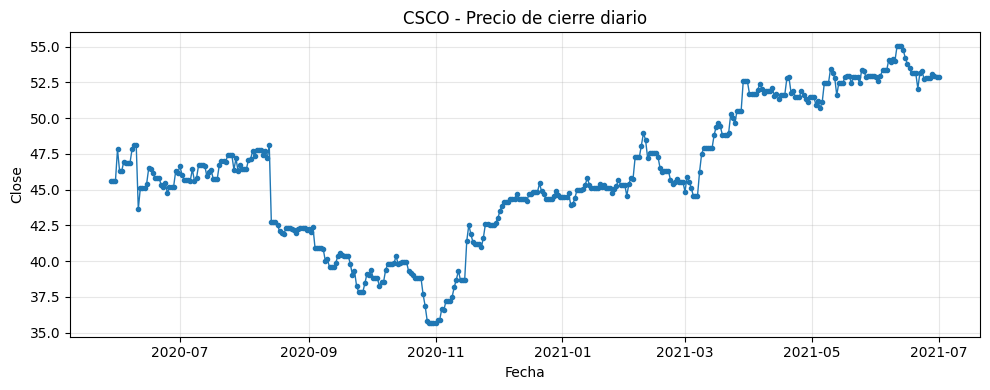

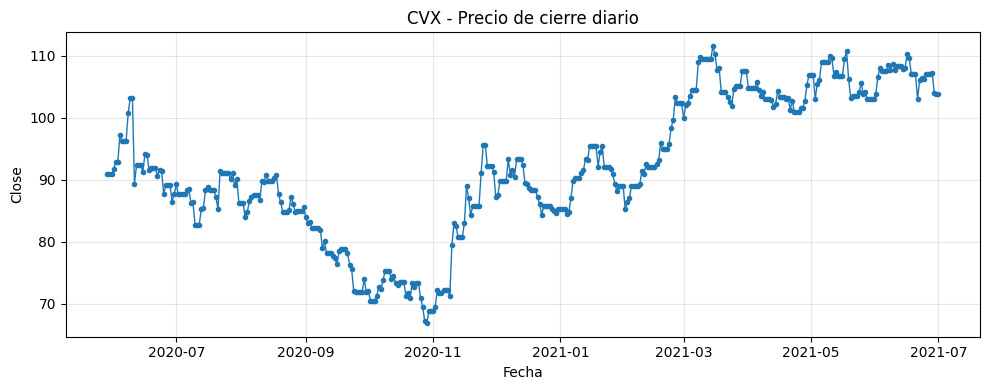

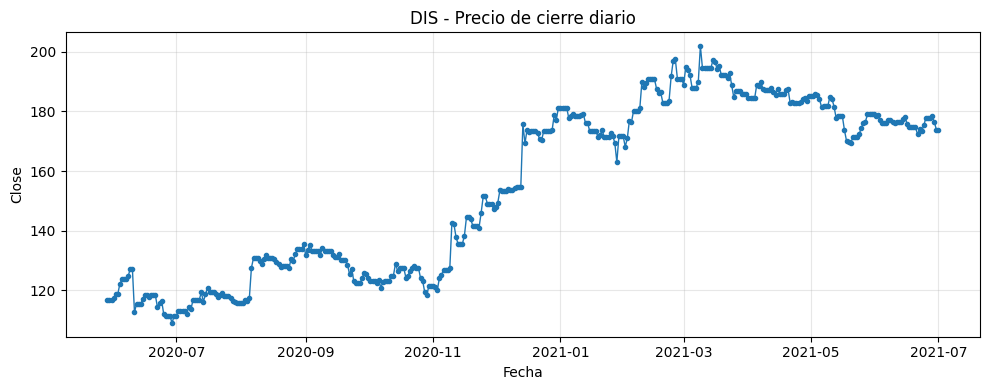

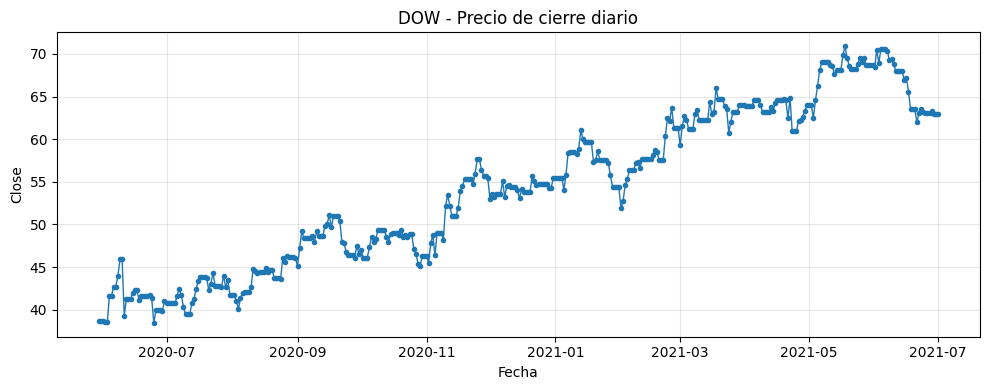

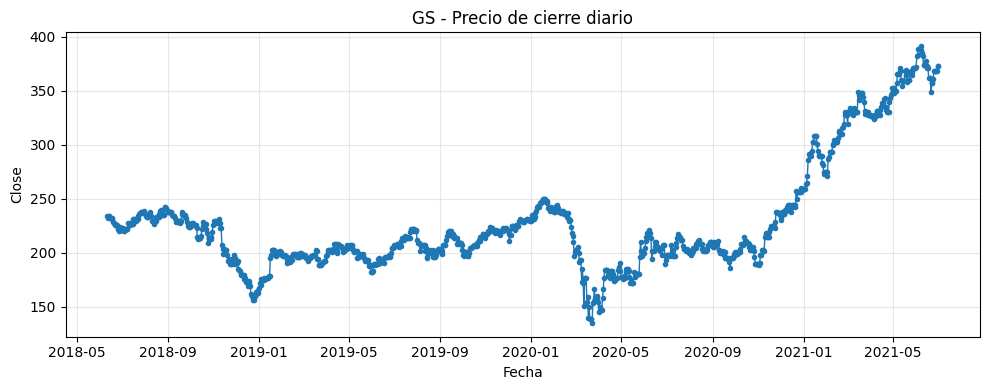

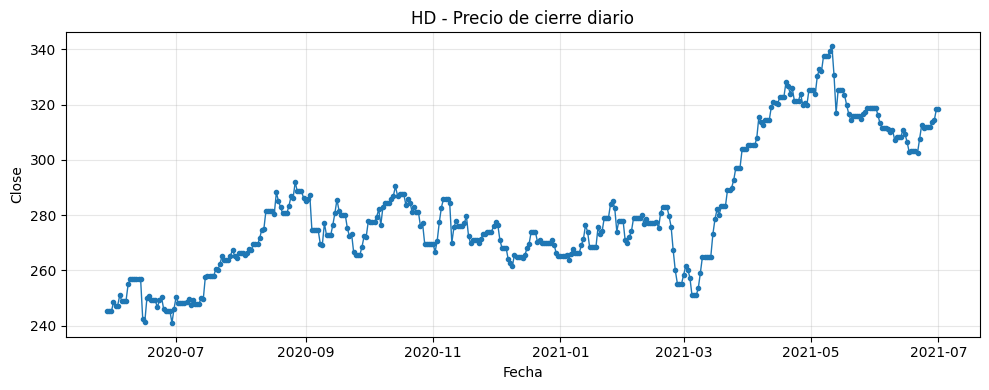

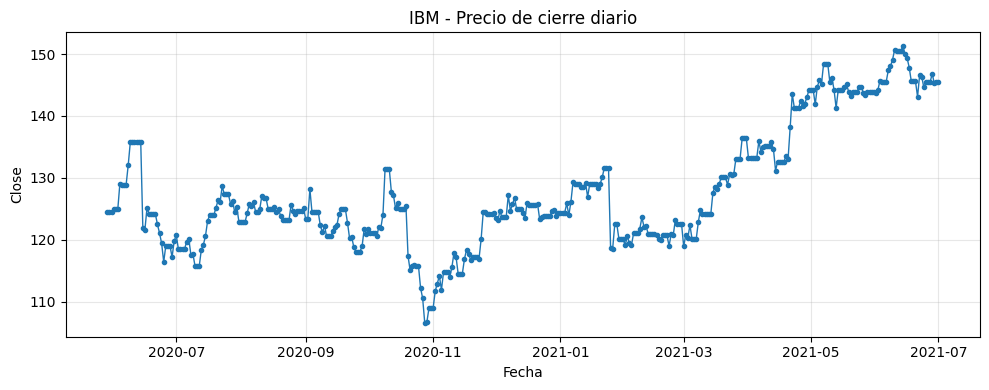

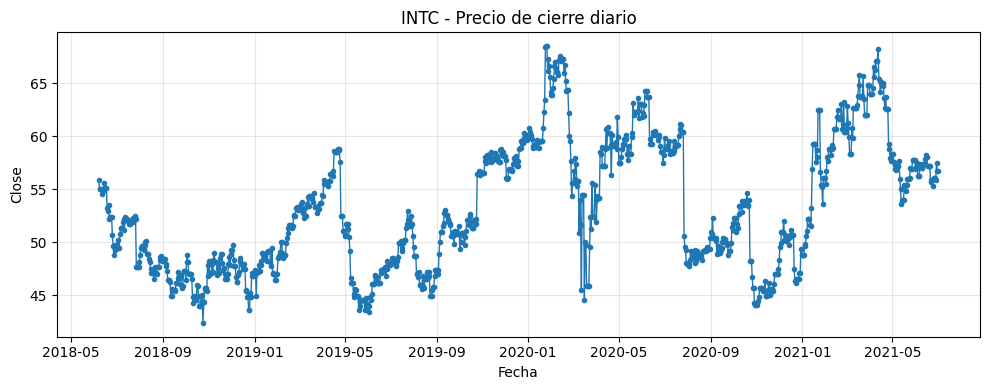

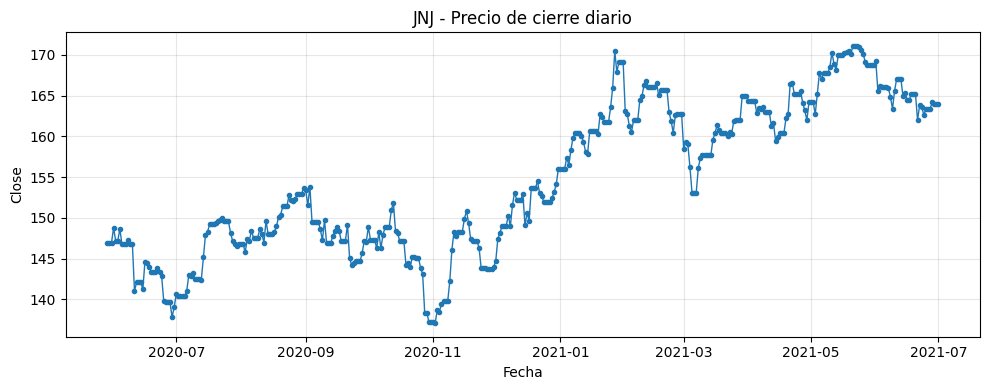

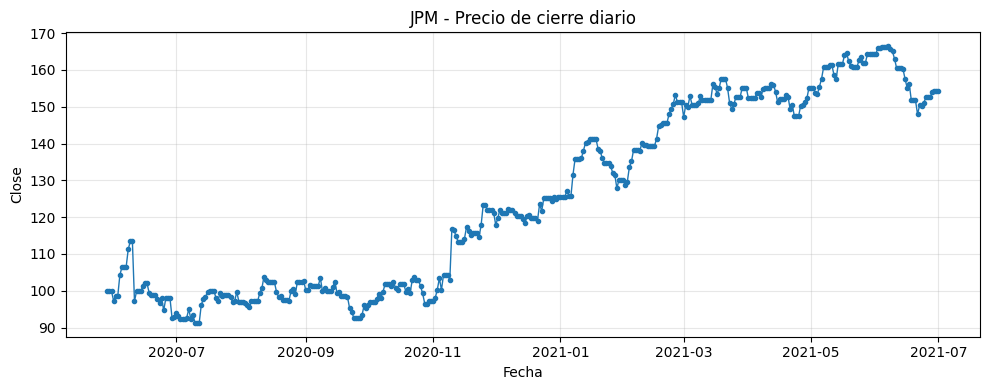

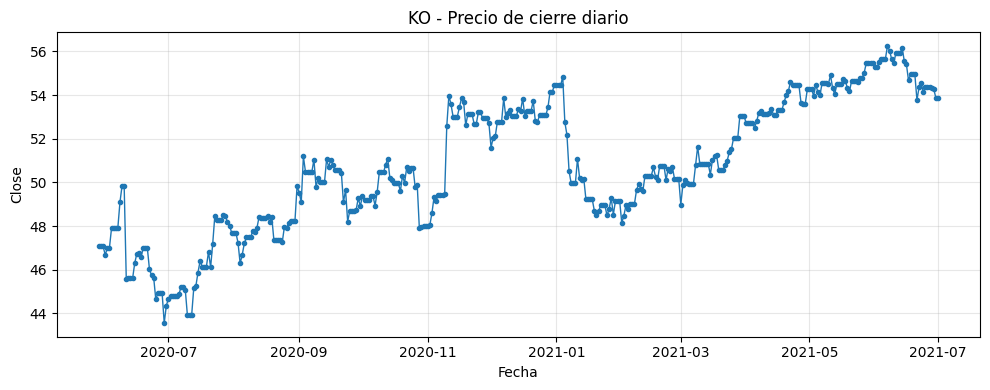

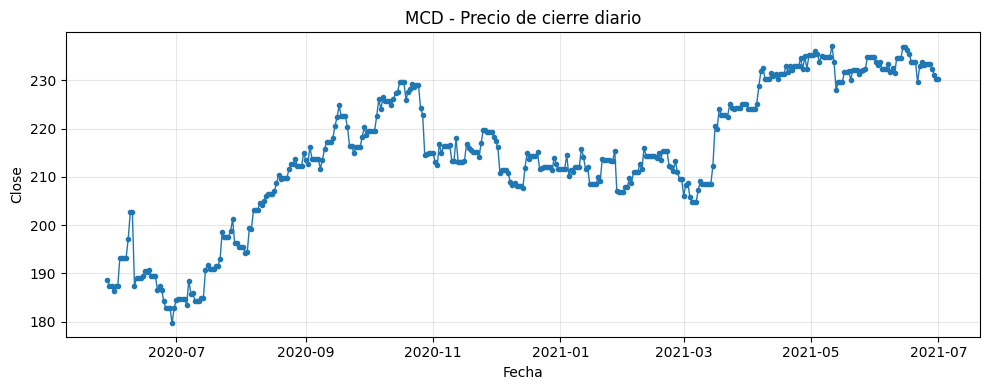

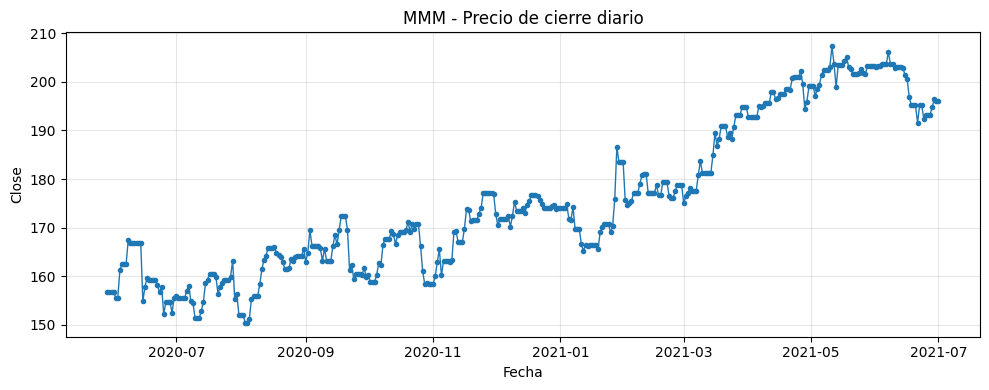

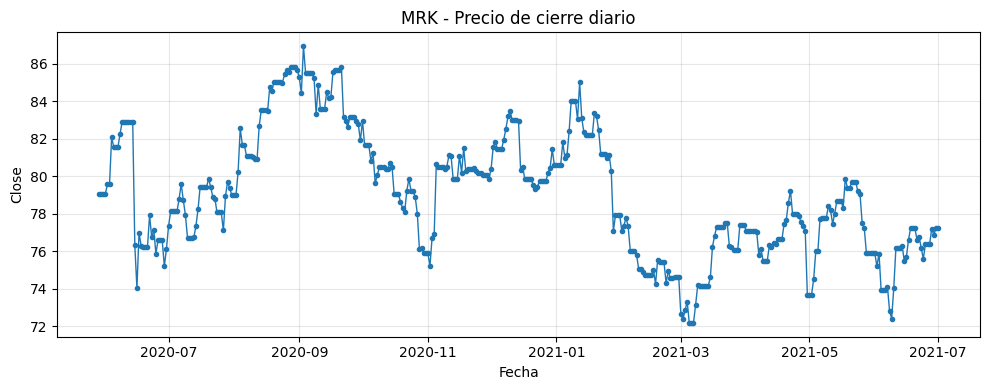

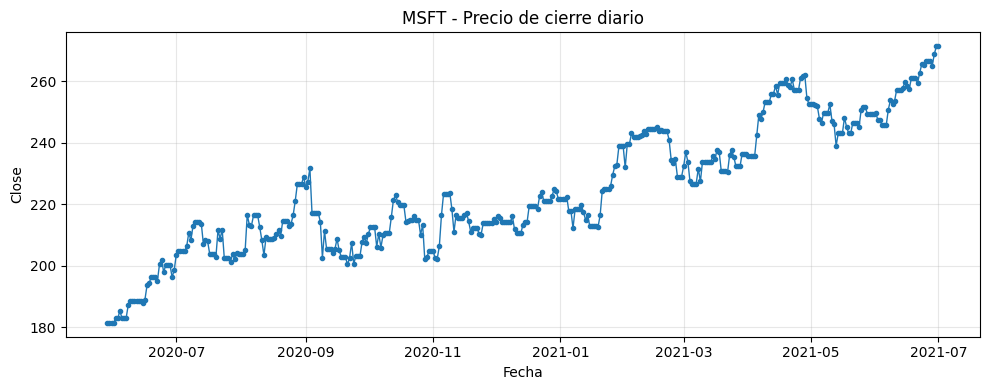

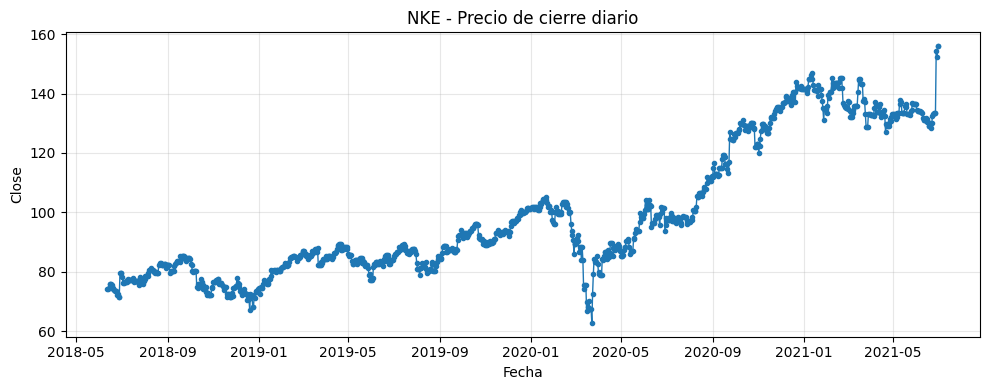

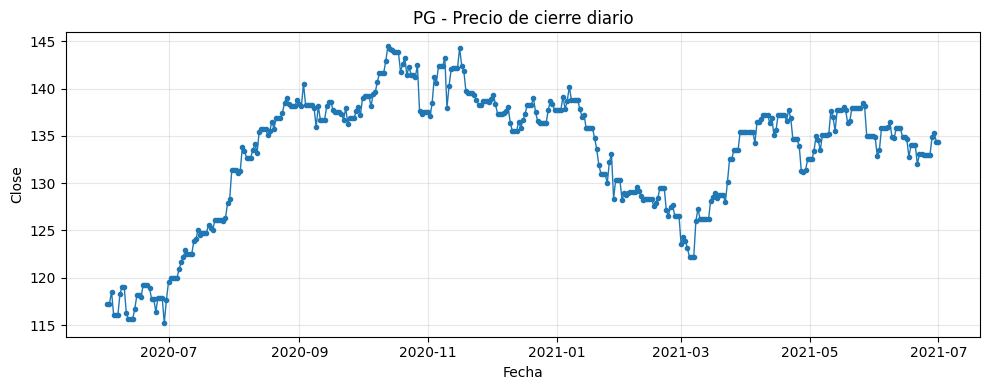

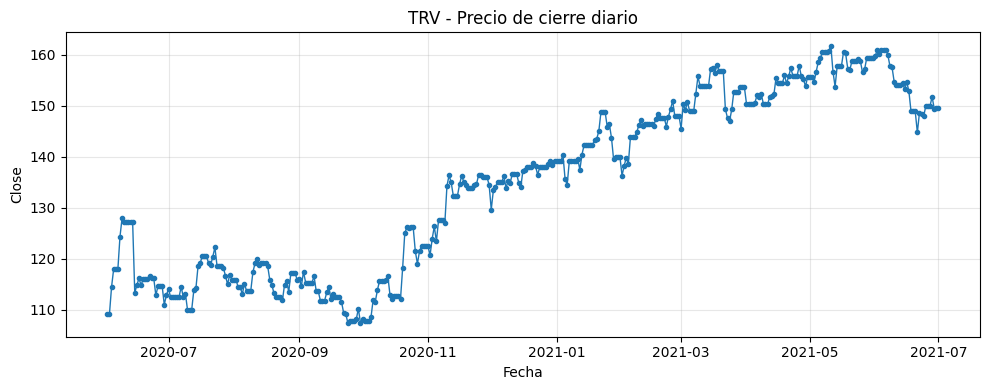

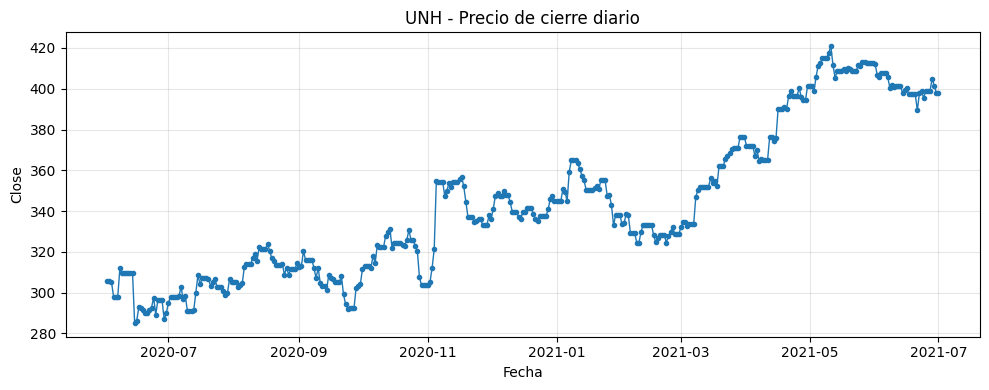

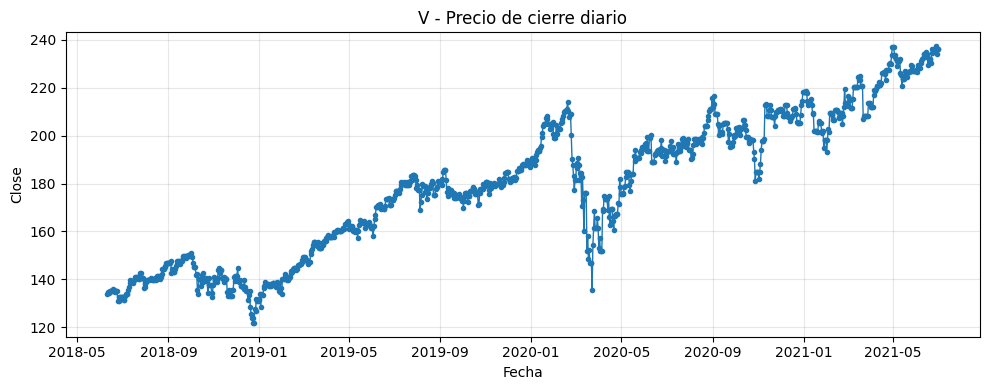

In [63]:
for sym, g in df_daily.groupby("symbol"):
    plt.figure(figsize=(10, 4))
    plt.plot(g["date"], g["close"], marker=".", linewidth=1)
    plt.title(f"{sym} - Precio de cierre diario")
    plt.xlabel("Fecha")
    plt.ylabel("Close")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


In [64]:
def ajustar_splits(): # hacer funcion para ajustar los splits: algo de coger el ultimo datos y ajustar a lo anteiror o algo asi
    return df_adj




Revisar NAs

In [65]:
print("\nNaNs por columna (en df_daily):")
print(df_daily.isna().sum())


NaNs por columna (en df_daily):
symbol    0
date      0
open      0
high      0
low       0
close     1
volume    0
dtype: int64


Sobre los ~800k NaNs → 1 NaN: normal si tuvieses muchos NaNs en columnas intradía (last, volume) y luego haces sum/last + ffill. Si quieres preservar información sobre días sin datos (en blanco) evita ffill sobre close en la fecha del split o marca las filas rellenadas con una bandera para no confundir con datos reales.